In [1]:
from rcwa4d import *
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from typing import Callable
%load_ext autoreload
%autoreload 2

In [2]:
number = int | float | complex
DEG = np.pi/180

In [3]:
def plate_pattern(n_total : number = 4):
    Ny=Nx=1000 ### resolution for dielectric pattern
    eps = np.ones([Ny,Nx])*4 ### uniform dielectric slab
    radius = 0.25
    thickness = 0.2
    xs,ys = np.linspace(-0.5,0.5,Nx), np.linspace(-0.5,0.5,Ny)
    xs,ys = np.meshgrid(xs,ys)
    eps[xs**2 + ys**2 < radius**2] = 1 ### air holes in dielectric slab
    ### size of truncation of reciprocal lattice:
    ind = 1
    NM = (2*ind+1)**2
    NMNM = NM**2
    ### frequencies to scan through:
    freqs = np.linspace(0.7,0.84,141)
    twists = np.linspace(0,45,46) * DEG
    kxs = np.linspace(0,0.5,51) ### in 2π/a units
    return eps, thickness, freqs, twists, kxs, ind, NM, NMNM

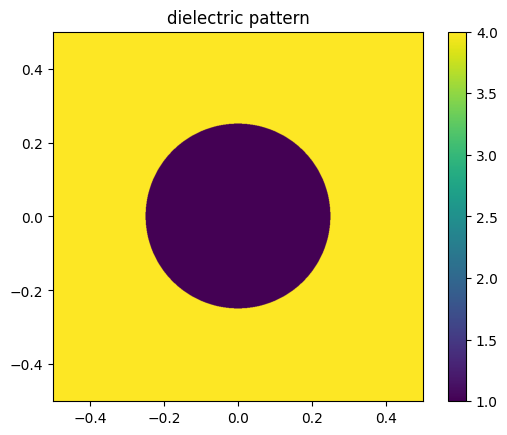

In [4]:
eps, thickness, freqs, twists, kxs, ind, NM, NMNM = plate_pattern()
plt.imshow(eps,extent=[-0.5,0.5,-0.5,0.5]); plt.colorbar(); plt.title('dielectric pattern'); plt.show()

In [5]:
def rod_pattern(n_total : number = 4):
    Ny=Nx=1000 ### resolution for dielectric pattern
    eps = np.ones([Ny,Nx])*4 ### uniform dielectric slab
    radius = 0.25
    thickness = 0.2
    xs,ys = np.linspace(-0.5,0.5,Nx), np.linspace(-0.5,0.5,Ny)
    xs,ys = np.meshgrid(xs,ys)
    eps[ys**2 < radius**2] = 1 ### air holes in dielectric slab
    ### size of truncation of reciprocal lattice:
    ind = 1
    NM = (2*ind+1)**2
    NMNM = NM**2
    ### frequencies to scan through:
    freqs = np.linspace(0.7,0.84,141)
    twists = np.linspace(0,45,46) * DEG
    kxs = np.linspace(0,0.5,51) ### in 2π/a units
    return eps, freqs, twists, kxs, NM, NMNM

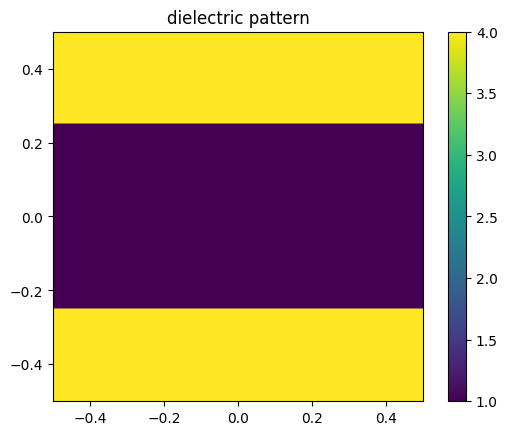

In [6]:
eps, freqs, twists, kxs, NM, NMNM = rod_pattern()
plt.imshow(eps,extent=[-0.5,0.5,-0.5,0.5]); plt.colorbar(); plt.title('dielectric pattern'); plt.show()

In [7]:
def calculate_freq_respect_kxs(n_total : number = 4, pattern: Callable = plate_pattern):
    eps, thickness, freqs, twists, kxs, ind, NM, NMNM = pattern(n_total)
    trans = []
    twist = 1*DEG
    for kx in tqdm(kxs):
        for freq in freqs:
            obj2 = rcwa([eps,eps], [thickness,thickness], [1,2],twist=twist, N=ind, M=ind, verbose=0)
            obj2.set_freq_k(freq, (kx, 0))
            (r,t), (reflected,transmitted) = obj2.get_RT(0,1)
            trans.append(t)
    return trans

trans = calculate_freq_respect_kxs()
trans = np.array(trans).reshape(len(kxs),len(freqs))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 51/51 [16:46<00:00, 19.73s/it]


In [8]:
def calculate_freq_respect_twist(n_total : number = 4, pattern: Callable = plate_pattern):
    eps, thickness, freqs, twists, kxs, ind, NM, NMNM = pattern(n_total)
    trans = []
    for twist in tqdm(twists):
        for freq in freqs:
            obj2 = rcwa([eps,eps], [thickness,thickness], [1,2],twist=twist, N=ind, M=ind, verbose=0)
            obj2.set_freq_k(freq, (0, 0))
            (r,t), (reflected,transmitted) = obj2.get_RT(0,1)
            trans.append(t)
            
trans = calculate_freq_respect_twist()
trans = np.array(trans).reshape(len(kxs),len(freqs))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [15:26<00:00, 20.14s/it]


ValueError: cannot reshape array of size 1 into shape (51,141)